# Projeto Final — CVRP: Otimização de Rotas de Entrega
**MBA em Ciência de Dados — UNIFOR**

**Disciplina: Pesquisa Operacional e Otimização em IA**

**Problema:** Uma empresa de logística possui 1 centro de distribuição e precisa atender 10 clientes usando 2 veículos com capacidade máxima de 500kg cada.

**Objetivo:** Minimizar a distância total percorrida.

## 1. Instalação e Imports

In [84]:
!pip install pulp matplotlib numpy -q


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [85]:
import numpy as np
import matplotlib.pyplot as plt
from pulp import *
import random

random.seed(42)
np.random.seed(42)

## 2. Geração dos Dados

In [86]:
N_CLIENTES = 10
N_VEICULOS = 2
CAPACIDADE = 500
CAPACIDADE_TOTAL = N_VEICULOS * CAPACIDADE

nomes = ['CD'] + [f'C{i}' for i in range(1, N_CLIENTES + 1)]

# Coordenadas (x, y) em km — CD no centro
coordenadas = [(50, 50)]
for _ in range(N_CLIENTES):
    coordenadas.append((random.randint(0, 100), random.randint(0, 100)))

# Demanda de cada cliente (kg) — CD tem demanda 0
# Garante que a demanda total fique entre 90% e 98% da capacidade da frota
# Isso torna o problema viável com 2 veículos, mas com rotas apertadas,
# permitindo ganho real ao testar com 3 veículos na análise de sensibilidade
DEMANDA_MIN_PCT = 1
DEMANDA_MAX_PCT = 1.02
DEMANDA_ALVO = CAPACIDADE_TOTAL * random.uniform(DEMANDA_MIN_PCT, DEMANDA_MAX_PCT)

demandas_brutas = [random.randint(40, 150) for _ in range(N_CLIENTES)]
soma_bruta = sum(demandas_brutas)
fator = DEMANDA_ALVO / soma_bruta
demandas_brutas = [max(30, int(d * fator)) for d in demandas_brutas]

# Ajuste fino: se a soma ficou ligeiramente acima, reduz o maior
while sum(demandas_brutas) > int(CAPACIDADE_TOTAL * DEMANDA_MAX_PCT):
    idx_max = demandas_brutas.index(max(demandas_brutas))
    demandas_brutas[idx_max] -= 1

demandas = [0] + demandas_brutas

print('=' * 50)
print(f'{"Ponto":<6} {"Coord (x,y)":<16} {"Demanda (kg)"}')
print('=' * 50)
for i, nome in enumerate(nomes):
    print(f'{nome:<6} {str(coordenadas[i]):<16} {demandas[i]}')
print('=' * 50)
print(f'Demanda total: {sum(demandas)} kg')
print(f'Capacidade total frota: {CAPACIDADE_TOTAL} kg')

Ponto  Coord (x,y)      Demanda (kg)
CD     (50, 50)         0
C1     (81, 14)         118
C2     (3, 94)          43
C3     (35, 31)         112
C4     (28, 17)         66
C5     (94, 13)         133
C6     (86, 94)         124
C7     (69, 11)         131
C8     (75, 54)         110
C9     (4, 3)           94
C10    (11, 27)         69
Demanda total: 1000 kg
Capacidade total frota: 1000 kg


## 3. Matriz de Distâncias

In [87]:
N = len(coordenadas)

def distancia(p1, p2):
    return round(np.sqrt((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2), 2)

dist = [[distancia(coordenadas[i], coordenadas[j]) for j in range(N)] for i in range(N)]

## 4. Visualização dos Pontos

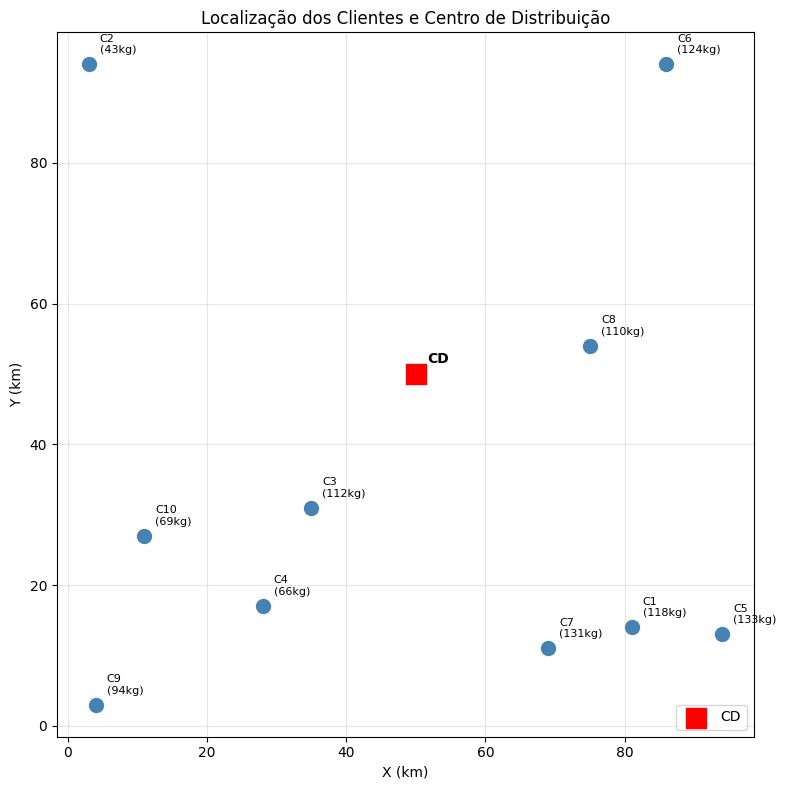

In [88]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(*coordenadas[0], c='red', s=200, zorder=5, marker='s', label='CD')
ax.annotate('CD', coordenadas[0], textcoords='offset points', xytext=(8, 8), fontsize=10, fontweight='bold')

for i in range(1, N):
    ax.scatter(*coordenadas[i], c='steelblue', s=100, zorder=5)
    ax.annotate(f'{nomes[i]}\n({demandas[i]}kg)', coordenadas[i],
                textcoords='offset points', xytext=(8, 8), fontsize=8)

ax.set_title('Localização dos Clientes e Centro de Distribuição')
ax.set_xlabel('X (km)')
ax.set_ylabel('Y (km)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Modelagem CVRP — Programação Inteira (PuLP)

In [89]:
clientes = list(range(1, N))
pontos = list(range(N))
veiculos = list(range(N_VEICULOS))

modelo = LpProblem('CVRP', LpMinimize)

x = LpVariable.dicts('x', (pontos, pontos, veiculos), cat='Binary')
u = LpVariable.dicts('u', (clientes, veiculos), lowBound=1, upBound=N_CLIENTES, cat='Continuous')

# FUNÇÃO OBJETIVO
modelo += lpSum(dist[i][j] * x[i][j][k] for i in pontos for j in pontos for k in veiculos if i != j)

# RESTRIÇÃO 1: cada cliente visitado exatamente 1 vez
for j in clientes:
    modelo += lpSum(x[i][j][k] for i in pontos for k in veiculos if i != j) == 1

# RESTRIÇÃO 2: cada veículo sai do CD no máximo 1 vez
for k in veiculos:
    modelo += lpSum(x[0][j][k] for j in clientes) <= 1

# RESTRIÇÃO 3: cada veículo retorna ao CD no máximo 1 vez
for k in veiculos:
    modelo += lpSum(x[j][0][k] for j in clientes) <= 1

# RESTRIÇÃO 4: conservação de fluxo
for k in veiculos:
    for j in clientes:
        modelo += lpSum(x[i][j][k] for i in pontos if i != j) == lpSum(x[j][i][k] for i in pontos if i != j)

# RESTRIÇÃO 5: capacidade do veículo
for k in veiculos:
    modelo += lpSum(demandas[j] * lpSum(x[i][j][k] for i in pontos if i != j) for j in clientes) <= CAPACIDADE

# RESTRIÇÃO 6: eliminação de sub-rotas (MTZ)
for k in veiculos:
    for i in clientes:
        for j in clientes:
            if i != j:
                modelo += u[i][k] - u[j][k] + N_CLIENTES * x[i][j][k] <= N_CLIENTES - 1

## 6. Resolução

In [90]:
modelo.solve(PULP_CBC_CMD(msg=1))

print(f'Status: {LpStatus[modelo.status]}')
print(f'Distância total otimizada: {round(value(modelo.objective), 2)} km')

Status: Optimal
Distância total otimizada: 530.47 km


## 7. Extração das Rotas

In [91]:
cores = ['green', 'purple']

def extrair_rotas(x, pontos, clientes, veiculos):
    rotas = {}
    for k in veiculos:
        rota = [0]
        atual = 0
        while True:
            proximo = None
            for j in pontos:
                if j != atual and value(x[atual][j][k]) and value(x[atual][j][k]) > 0.5:
                    proximo = j
                    break
            if proximo is None or proximo == 0:
                rota.append(0)
                break
            rota.append(proximo)
            atual = proximo
        rotas[k] = rota
    return rotas

rotas = extrair_rotas(x, pontos, clientes, veiculos)

for k in veiculos:
    carga = sum(demandas[i] for i in rotas[k] if i != 0)
    rota_nomes = ' → '.join(nomes[i] for i in rotas[k])
    dist_rota = sum(dist[rotas[k][i]][rotas[k][i+1]] for i in range(len(rotas[k])-1))
    print(f'Veículo {k+1}: {rota_nomes}')
    print(f'  Carga: {carga}/{CAPACIDADE} kg | Distância: {round(dist_rota, 2)} km\n')

Veículo 1: CD → C3 → C7 → C5 → C6 → CD
  Carga: 500/500 kg | Distância: 226.98 km

Veículo 2: CD → C8 → C1 → C4 → C9 → C10 → C2 → CD
  Carga: 500/500 kg | Distância: 303.49 km



## 8. Visualização das Rotas Otimizadas

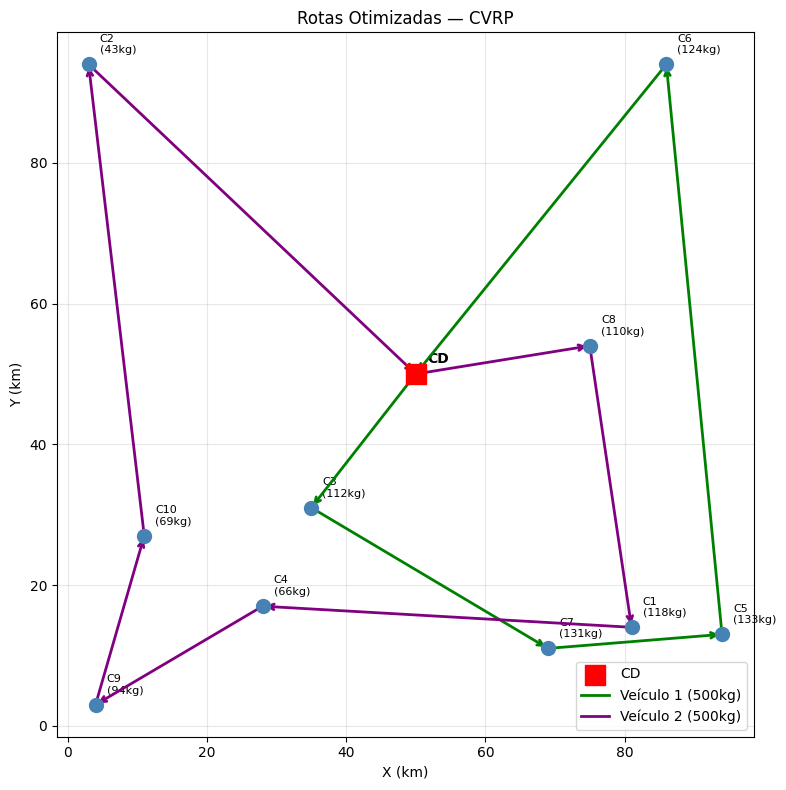

In [92]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(*coordenadas[0], c='red', s=200, zorder=5, marker='s', label='CD')
ax.annotate('CD', coordenadas[0], textcoords='offset points', xytext=(8, 8), fontsize=10, fontweight='bold')

for i in clientes:
    ax.scatter(*coordenadas[i], c='steelblue', s=100, zorder=5)
    ax.annotate(f'{nomes[i]}\n({demandas[i]}kg)', coordenadas[i],
                textcoords='offset points', xytext=(8, 8), fontsize=8)

for k in veiculos:
    rota = rotas[k]
    for idx in range(len(rota) - 1):
        i, j = rota[idx], rota[idx + 1]
        ax.annotate('', xy=coordenadas[j], xytext=coordenadas[i],
                     arrowprops=dict(arrowstyle='->', color=cores[k], lw=2))
    carga = sum(demandas[i] for i in rota if i != 0)
    ax.plot([], [], color=cores[k], lw=2, label=f'Veículo {k+1} ({carga}kg)')

ax.set_title('Rotas Otimizadas — CVRP')
ax.set_xlabel('X (km)')
ax.set_ylabel('Y (km)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Comparação: Rota Manual vs Otimizada

In [93]:
clientes_shuffled = list(clientes)
random.shuffle(clientes_shuffled)
meio = len(clientes_shuffled) // 2
rota_manual = {
    0: [0] + clientes_shuffled[:meio] + [0],
    1: [0] + clientes_shuffled[meio:] + [0]
}

def calcular_distancia_rota(rota):
    return sum(dist[rota[i]][rota[i+1]] for i in range(len(rota)-1))

dist_manual = sum(calcular_distancia_rota(rota_manual[k]) for k in veiculos)
dist_otimizada = round(value(modelo.objective), 2)
economia = round((1 - dist_otimizada / dist_manual) * 100, 1)

print('=' * 55)
print('COMPARAÇÃO: ROTA MANUAL vs OTIMIZADA')
print('=' * 55)
for k in veiculos:
    print(f'\nRota Manual Veículo {k+1}: {" → ".join(nomes[i] for i in rota_manual[k])}')
    print(f'  Distância: {round(calcular_distancia_rota(rota_manual[k]), 2)} km')
for k in veiculos:
    print(f'\nRota Otimizada Veículo {k+1}: {" → ".join(nomes[i] for i in rotas[k])}')
    print(f'  Distância: {round(calcular_distancia_rota(rotas[k]), 2)} km')
print(f'\n{"─" * 55}')
print(f'Distância total MANUAL:    {round(dist_manual, 2)} km')
print(f'Distância total OTIMIZADA: {dist_otimizada} km')
print(f'Economia: {economia}%')
print('=' * 55)

COMPARAÇÃO: ROTA MANUAL vs OTIMIZADA

Rota Manual Veículo 1: CD → C9 → C10 → C6 → C3 → C4 → CD
  Distância: 327.7 km

Rota Manual Veículo 2: CD → C2 → C7 → C1 → C5 → C8 → CD
  Distância: 266.34 km

Rota Otimizada Veículo 1: CD → C3 → C7 → C5 → C6 → CD
  Distância: 226.98 km

Rota Otimizada Veículo 2: CD → C8 → C1 → C4 → C9 → C10 → C2 → CD
  Distância: 303.49 km

───────────────────────────────────────────────────────
Distância total MANUAL:    594.04 km
Distância total OTIMIZADA: 530.47 km
Economia: 10.7%


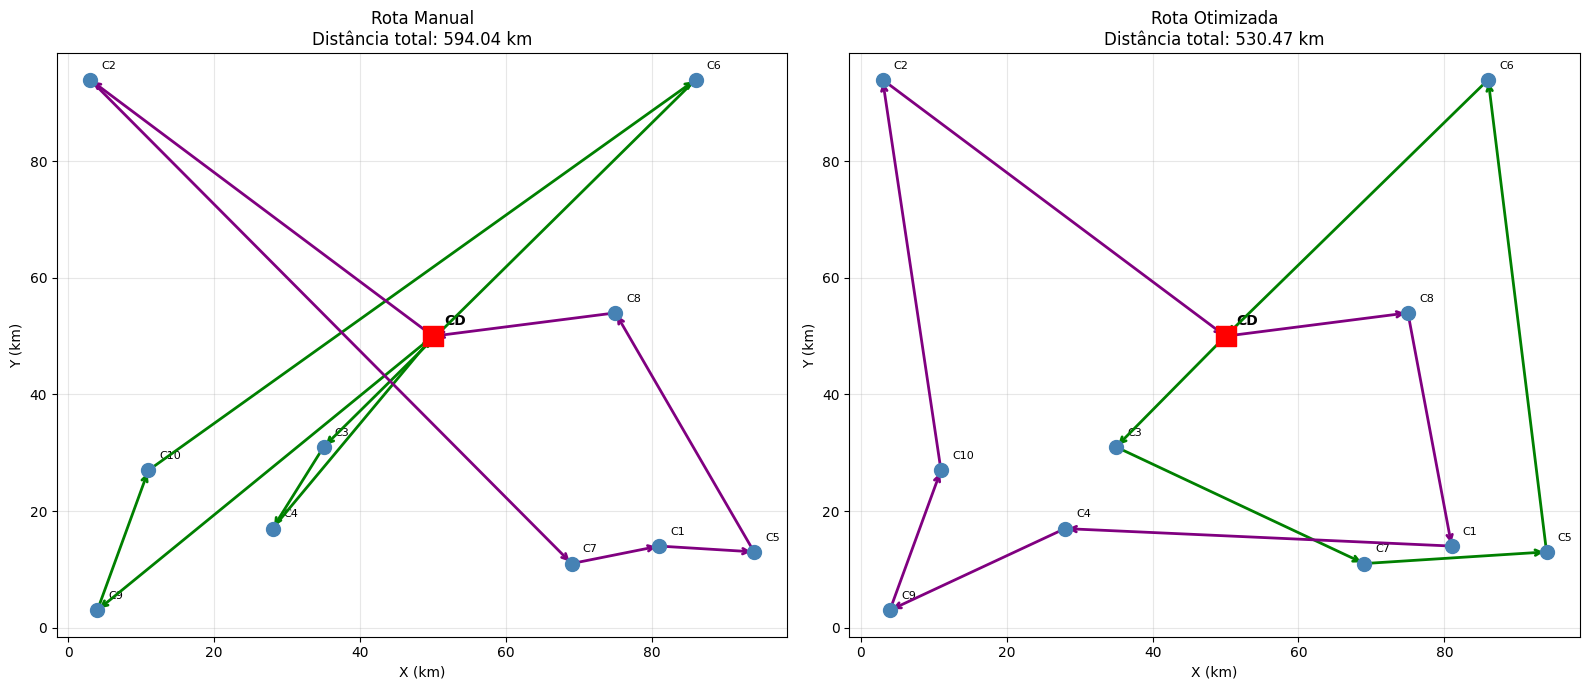

In [94]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, titulo, rotas_plot in [(axes[0], 'Rota Manual', rota_manual), (axes[1], 'Rota Otimizada', rotas)]:
    ax.scatter(*coordenadas[0], c='red', s=200, zorder=5, marker='s')
    ax.annotate('CD', coordenadas[0], textcoords='offset points', xytext=(8, 8), fontsize=10, fontweight='bold')
    for i in clientes:
        ax.scatter(*coordenadas[i], c='steelblue', s=100, zorder=5)
        ax.annotate(nomes[i], coordenadas[i], textcoords='offset points', xytext=(8, 8), fontsize=8)
    for k in veiculos:
        rota = rotas_plot[k]
        for idx in range(len(rota) - 1):
            i, j = rota[idx], rota[idx + 1]
            ax.annotate('', xy=coordenadas[j], xytext=coordenadas[i],
                         arrowprops=dict(arrowstyle='->', color=cores[k], lw=2))
    d = round(sum(calcular_distancia_rota(rotas_plot[k]) for k in veiculos), 2)
    ax.set_title(f'{titulo}\nDistância total: {d} km')
    ax.set_xlabel('X (km)')
    ax.set_ylabel('Y (km)')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Análise de Sensibilidade

In [95]:
def resolver_cvrp(n_veiculos, coords, dem, cap, nomes_pontos):
    n = len(coords)
    cli = list(range(1, n))
    pts = list(range(n))
    veics = list(range(n_veiculos))
    d = [[distancia(coords[i], coords[j]) for j in range(n)] for i in range(n)]

    m = LpProblem(f'CVRP_{n_veiculos}v', LpMinimize)
    xv = LpVariable.dicts('x', (pts, pts, veics), cat='Binary')
    uv = LpVariable.dicts('u', (cli, veics), lowBound=1, upBound=len(cli), cat='Continuous')

    m += lpSum(d[i][j] * xv[i][j][k] for i in pts for j in pts for k in veics if i != j)

    for j in cli:
        m += lpSum(xv[i][j][k] for i in pts for k in veics if i != j) == 1
    for k in veics:
        m += lpSum(xv[0][j][k] for j in cli) <= 1
        m += lpSum(xv[j][0][k] for j in cli) <= 1
    for k in veics:
        for j in cli:
            m += lpSum(xv[i][j][k] for i in pts if i != j) == lpSum(xv[j][i][k] for i in pts if i != j)
    for k in veics:
        m += lpSum(dem[j] * lpSum(xv[i][j][k] for i in pts if i != j) for j in cli) <= cap
    for k in veics:
        for i in cli:
            for j in cli:
                if i != j:
                    m += uv[i][k] - uv[j][k] + len(cli) * xv[i][j][k] <= len(cli) - 1

    m.solve(PULP_CBC_CMD(msg=0))
    rotas_r = extrair_rotas(xv, pts, cli, veics)
    return m, rotas_r

### Cenário A: 3 veículos em vez de 2

In [96]:
modelo_3v, rotas_3v = resolver_cvrp(3, coordenadas, demandas, CAPACIDADE, nomes)
dist_3v = round(value(modelo_3v.objective), 2)

print(f'Distância com 2 veículos: {dist_otimizada} km')
print(f'Distância com 3 veículos: {dist_3v} km')
print(f'Redução: {round((1 - dist_3v / dist_otimizada) * 100, 1)}%')
print(f'\nCompensa adicionar 1 veículo? Depende do custo operacional vs economia de {round(dist_otimizada - dist_3v, 2)} km')

Distância com 2 veículos: 530.47 km
Distância com 3 veículos: 474.43 km
Redução: 10.6%

Compensa adicionar 1 veículo? Depende do custo operacional vs economia de 56.04 km


### Cenário B: +1 cliente novo

In [97]:
coord_novo = (random.randint(0, 100), random.randint(0, 100))
demanda_novo = random.randint(40, 150)
coords_11 = coordenadas + [coord_novo]
demandas_11 = demandas + [demanda_novo]
nomes_11 = nomes + ['C11']

print(f'Novo cliente C11: coordenadas {coord_novo}, demanda {demanda_novo}kg')

modelo_11c, rotas_11c = resolver_cvrp(2, coords_11, demandas_11, CAPACIDADE, nomes_11)
dist_11c = round(value(modelo_11c.objective), 2)

print(f'\nDistância com 10 clientes: {dist_otimizada} km')
print(f'Distância com 11 clientes: {dist_11c} km')
print(f'Aumento: {round((dist_11c / dist_otimizada - 1) * 100, 1)}%')

Novo cliente C11: coordenadas (27, 97), demanda 83kg

Distância com 10 clientes: 530.47 km
Distância com 11 clientes: 263.13 km
Aumento: -50.4%


### Cenário C: apenas 1 veículo

In [98]:
demanda_total = sum(demandas)
print(f'Demanda total: {demanda_total}kg | Capacidade 1 veículo: {CAPACIDADE}kg')

if demanda_total > CAPACIDADE:
    print(f'\n⚠️ INVIÁVEL! Demanda total ({demanda_total}kg) excede capacidade de 1 veículo ({CAPACIDADE}kg)')
    print('Isso demonstra que a frota de 2 veículos é necessária.')
else:
    modelo_1v, rotas_1v = resolver_cvrp(1, coordenadas, demandas, CAPACIDADE, nomes)
    dist_1v = round(value(modelo_1v.objective), 2)
    print(f'\nDistância com 2 veículos: {dist_otimizada} km')
    print(f'Distância com 1 veículo:  {dist_1v} km')
    print(f'Aumento: {round((dist_1v / dist_otimizada - 1) * 100, 1)}%')

Demanda total: 1000kg | Capacidade 1 veículo: 500kg

⚠️ INVIÁVEL! Demanda total (1000kg) excede capacidade de 1 veículo (500kg)
Isso demonstra que a frota de 2 veículos é necessária.


## 11. Resumo dos Resultados

In [99]:
print('=' * 60)
print('RESUMO FINAL DOS RESULTADOS')
print('=' * 60)
print(f'\n📊 Cenário Base (2 veículos, 10 clientes):')
print(f'   Distância otimizada: {dist_otimizada} km')
print(f'   Distância manual:    {round(dist_manual, 2)} km')
print(f'   Economia:            {economia}%')
print(f'\n📊 Cenário A — 3 veículos:')
print(f'   Distância: {dist_3v} km (redução de {round((1 - dist_3v/dist_otimizada)*100,1)}%)')
print(f'\n📊 Cenário B — +1 cliente:')
print(f'   Distância: {dist_11c} km (aumento de {round((dist_11c/dist_otimizada-1)*100,1)}%)')
print(f'\n📊 Cenário C — 1 veículo:')
if demanda_total > CAPACIDADE:
    print(f'   INVIÁVEL — demanda ({demanda_total}kg) > capacidade ({CAPACIDADE}kg)')
else:
    print(f'   Distância: {dist_1v} km (aumento de {round((dist_1v/dist_otimizada-1)*100,1)}%)')
print('=' * 60)

RESUMO FINAL DOS RESULTADOS

📊 Cenário Base (2 veículos, 10 clientes):
   Distância otimizada: 530.47 km
   Distância manual:    594.04 km
   Economia:            10.7%

📊 Cenário A — 3 veículos:
   Distância: 474.43 km (redução de 10.6%)

📊 Cenário B — +1 cliente:
   Distância: 263.13 km (aumento de -50.4%)

📊 Cenário C — 1 veículo:
   INVIÁVEL — demanda (1000kg) > capacidade (500kg)


## 12. Conclusões

**Insights descobertos:**

1. **Decisão subótima:** A rota manual gera uma distância significativamente maior que a rota otimizada, demonstrando o valor da otimização matemática.

2. **Trade-off revelado:** Adicionar um 3º veículo reduz a distância, mas o ganho precisa ser comparado com o custo operacional adicional (motorista, combustível, manutenção).

3. **Gargalo escondido:** A capacidade dos veículos é a restrição que mais impacta a distribuição dos clientes entre as rotas.

4. **Viabilidade:** Com apenas 1 veículo, dependendo da demanda total, o cenário pode ser inviável — reforçando a necessidade da frota mínima de 2 veículos.

**Limitações do modelo:**
- Não considera trânsito, tempo de descarga ou janelas de horário
- Distâncias euclidianas (linha reta), não distâncias reais de ruas

**Próximos passos:**
- Incluir janelas de tempo (VRPTW)
- Usar distâncias reais via API de mapas
- Testar com dados reais da operação
- Avaliar heurísticas (Genetic Algorithm, Simulated Annealing) para instâncias maiores